# Task 5.2

Выполнено:
- чтение изображения через OpenCV;
- вейвлет-преобразование Хаара;
- повторное Хаар-преобразование для `cA`;
- обнуление коэффициентов `cA1` по порогу `threshold = 40`;
- подсчет числа обнуленных коэффициентов и отображение результата.

Количество обнуленных коэффициентов cA1: 20


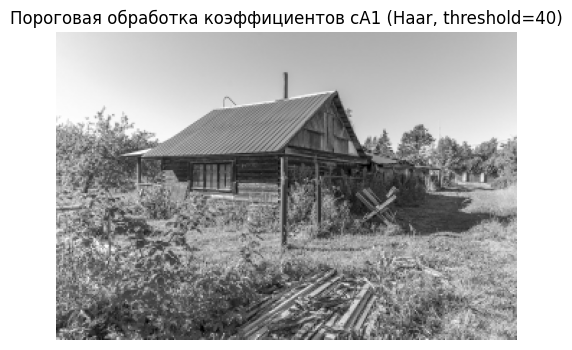

In [1]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread("image.jpg")
if img_bgr is None:
    raise FileNotFoundError("Не удалось прочитать image.jpg")

image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

cA, (cH, cV, cD) = pywt.dwt2(image, "haar")

cA1, (cH1, cV1, cD1) = pywt.dwt2(cA, "haar")

threshold = 40
mask = np.abs(cA1) < threshold
zeroed_count = int(np.count_nonzero(mask))
cA1_thresholded = cA1.copy()
cA1_thresholded[mask] = 0

print(f"Количество обнуленных коэффициентов cA1: {zeroed_count}")

plt.figure(figsize=(8, 4))
plt.imshow(cA1_thresholded, cmap="gray")
plt.title("Пороговая обработка коэффициентов cA1 (Haar, threshold=40)")
plt.axis("off")
plt.show()